In [108]:
from tqdm.notebook import tqdm
from shapely.geometry import shape, mapping, Point, Polygon
import pandas as pd
import numpy as np
#import geoio
import os
import geopandas as gpd
import matplotlib.pyplot as plt

from shapely import wkt
from shapely.geometry import Point, Polygon
from shapely.wkt import loads
%matplotlib inline
from matplotlib.patches import Patch

BASE_DIR = '..'
SHAPEFILES_DIR = os.path.join(BASE_DIR, 'data', 'shapefiles')
IDHM_DIR = os.path.join(BASE_DIR, 'data', 'Processed')
OUTPUT_DIR = os.path.join(BASE_DIR, 'data', 'Processed')

##### Read shapefile raw data

In [72]:
# Read file shapefiles (these files where obtained from QGis by filtering those CT that belong to the selected mirrors and treated from PARSEC)
#raw data
df_Mirrors = gpd.read_file(os.path.join(SHAPEFILES_DIR,'Mirrors_PARSEC_CT_.dbf'))
df_Treated = gpd.read_file(os.path.join(SHAPEFILES_DIR,'Treated_PARSEC_CT_.dbf'))

#choose only columns
df_Mirrors = df_Mirrors[['CD_GEOCODI', 'TIPO', 'CD_GEOCODM', 'NM_MUNICIP','geometry']]
df_Treated = df_Treated[['CD_GEOCODI', 'TIPO', 'CD_GEOCODM', 'NM_MUNICIP','geometry']]

print("SHAPE Mirrors: "+str(df_Mirrors.shape))
print("SHAPE Treateds: "+str(df_Treated.shape))

SHAPE Mirrors: (319, 5)
SHAPE Treateds: (349, 5)


In [75]:
# add column to identify mirror and treated 
df_Mirrors.insert(5, 'is_mirror', 'TRUE')
df_Treated.insert(5, 'is_mirror', 'FALSE')

In [93]:
#concat Mirrors and treated
geo_Brazil =  pd.concat([df_Treated, df_Mirrors], ignore_index=True)

geo_Brazil['CD_GEOCODI'] = geo_Brazil['CD_GEOCODI'].astype(str) 
print("SHAPE CLUSTERS (M+T): "+str(geo_Brazil.shape))
geo_Brazil.sample(10)


SHAPE CLUSTERS (M+T): (668, 6)


,CD_GEOCODI,TIPO,CD_GEOCODM,NM_MUNICIP,geometry,is_mirror
66,220552405000010,RURAL,2205524,JÚLIO BORGES,"POLYGON ((-44.241 -10.339, -44.239 -10.340, -4...",FALSE
120,290910905000010,RURAL,2909109,CORIBE,"POLYGON ((-44.580 -13.687, -44.580 -13.687, -4...",FALSE
512,292265605000005,RURAL,2922656,NORDESTINA,"POLYGON ((-39.370 -10.777, -39.369 -10.778, -3...",TRUE
280,510337905000012,RURAL,5103379,COTRIGUAÇU,"POLYGON ((-58.944 -9.365, -58.932 -9.363, -58....",FALSE
317,510629905000018,URBANO,5106299,PARANAÍTA,"POLYGON ((-56.465 -9.666, -56.458 -9.666, -56....",FALSE
593,510706505000006,RURAL,5107065,QUERÊNCIA,"POLYGON ((-53.464 -11.596, -53.461 -11.616, -5...",TRUE
251,293315805000011,RURAL,2933158,VÁRZEA NOVA,"POLYGON ((-41.039 -11.214, -41.041 -11.217, -4...",FALSE
328,520082905000001,URBANO,5200829,AMARALINA,"POLYGON ((-49.298 -13.919, -49.297 -13.919, -4...",FALSE
359,220207505000002,RURAL,2202075,CAJAZEIRAS DO PIAUÍ,"POLYGON ((-42.508 -6.746, -42.506 -6.747, -42....",TRUE
436,220560705000006,URBANO,2205607,LANDRI SALES,"POLYGON ((-43.928 -7.271, -43.923 -7.274, -43....",TRUE


##### Read indicators file IDH calculated

In [76]:
#Read the IDH_CT from Brazil
df_indicators = pd.read_csv(os.path.join(IDHM_DIR,'BRAZIL_IDHct.csv'))#renda alfabet  longev.
df_indicators['Cod_setor'] = df_indicators['Cod_setor'].astype(str) 

df_indicators = df_indicators.rename(columns={'LongevIDHCT': 'longevity','AlfabIDHCT': 'literacy', 'RendaIDHCT': 'income', 'IDHCT-FULL':'IDH_CT'})
print("SHAPE CT: "+str(df_indicators.shape))
print(df_indicators.columns)


SHAPE CT: (303845, 5)
Index(['Cod_setor', 'longevity', 'literacy', 'income', 'IDH_CT'], dtype='object')


In [77]:
df_indicators.sample(5)

,Cod_setor,longevity,literacy,income,IDH_CT
26943,292740805070011,0.9166666666666666,0.9915254237288136,0.7105695009129488,0.872920530436143
177892,330414405060013,0.75,0.9654436367832006,0.5648757846693332,0.7601064738175113
57948,520030805000019,0.8666666666666667,0.9429508196721311,0.6173765397974564,0.8089980087120848
218,120030205000029,0.48333333333333334,0.28295058235177994,0.24944120614889828,0.3385750406113372
262552,350950205000989,0.75,0.9813660563563174,0.589209371513881,0.7735251426233994


In [113]:
#remove empty indicators, some CT may have Income but not Longevity or Literacy
nan_value = float("NaN")
#Convert NaN values to empty string
df_indicators.replace("", nan_value, inplace=True)
df_indicators.dropna(subset = ["longevity"], inplace=True)
df_indicators.dropna(subset = ["literacy"], inplace=True)
df_indicators.dropna(subset = ["income"], inplace=True)

print("SHAPE CT: "+str(df_indicators.shape))

SHAPE CT: (302676, 5)


## Calculate centroid for each cluster

In [136]:
#start process cluster  
pd_joined_cluster = pd.merge(geo_Brazil, df_indicators,  how='inner', left_on='CD_GEOCODI', right_on='Cod_setor')
print("SHAPE JOINED CLUSTER: "+str(pd_joined_cluster.shape))

columns_to_show=['Cod_setor', 'TIPO','is_mirror','NM_MUNICIP','income','longevity','literacy','IDH_CT','geometry']
df_BR_available=pd_joined_cluster[columns_to_show]


SHAPE JOINED CLUSTER: (633, 11)


In [137]:
df_BR_available.sample(10)

,Cod_setor,TIPO,is_mirror,NM_MUNICIP,income,longevity,literacy,IDH_CT,geometry
147,291200405000019,RURAL,FALSE,IBIASSUCÊ,0.41394683250296815,0.7666666666666667,0.8989898989898991,0.6932011327198446,"POLYGON ((-42.346 -14.197, -42.342 -14.199, -4..."
410,220530005000004,RURAL,TRUE,JERUMENHA,0.4714360085011115,0.8666666666666667,0.8657407407407408,0.7346144719695064,"POLYGON ((-43.487 -6.829, -43.486 -6.831, -43...."
217,293310905000004,URBANO,FALSE,VÁRZEA DO POÇO,0.4640687588765282,0.7666666666666667,0.7632398753894081,0.664658433644201,"POLYGON ((-40.315 -11.528, -40.315 -11.528, -4..."
202,292905705000017,URBANO,FALSE,SÃO FÉLIX DO CORIBE,0.5060695737847326,0.7666666666666667,0.9292320213080792,0.7339894205864929,"POLYGON ((-44.190 -13.403, -44.190 -13.404, -4..."
18,210083205000020,RURAL,FALSE,APICUM-AÇU,0.3441080825450661,0.65,0.8614663796378371,0.6185248207276345,"MULTIPOLYGON (((-45.122 -1.644, -45.124 -1.642..."
242,293315805000011,RURAL,FALSE,VÁRZEA NOVA,0.3533699641316288,0.6833333333333333,0.890909090909091,0.642537462791351,"POLYGON ((-41.039 -11.214, -41.041 -11.217, -4..."
369,220435205000005,RURAL,TRUE,GEMINIANO,0.41524997192723234,0.7666666666666667,0.7112025229672289,0.631039720520376,"POLYGON ((-41.298 -7.195, -41.297 -7.195, -41...."
252,293315805000021,RURAL,FALSE,VÁRZEA NOVA,0.4098085318902805,0.6333333333333333,0.834759951333484,0.6259672721856993,"POLYGON ((-40.970 -11.269, -40.970 -11.269, -4..."
187,292905705000002,URBANO,FALSE,SÃO FÉLIX DO CORIBE,0.6341477709887168,0.9,0.9614676788589832,0.8318718166158999,"POLYGON ((-44.197 -13.399, -44.196 -13.399, -4..."
500,292265605000009,RURAL,TRUE,NORDESTINA,0.2686386094105204,0.7166666666666667,0.7583262242673353,0.5812105001148408,"POLYGON ((-39.445 -10.776, -39.445 -10.778, -3..."


In [139]:
#Find the center point 
df_BR_available['Center_point'] = df_BR_available['geometry'].centroid.to_crs(epsg=3857)
# Extract lat and lon from the centerpoint
#Latitude is the Y axis, longitude is the X axis.
df_BR_available['lon'] = df_BR_available['Center_point'].map(lambda p: p.x)
df_BR_available['lat'] = df_BR_available['Center_point'].map(lambda p: p.y)

In [132]:
municipiosMirror_Treated = ['alto boa vista','amaralina','apicum-açu','avelino lopes','bertolínia','caldeirão grande','canavieira','coribe','cotriguaçu','ibiassucê','júlio borges','morro cabeça no tempo','novo planalto','paranaíta','ponto novo','são félix do coribe','sebastião barros','serra nova dourada','várzea do poço','várzea nova','cajazeiras do piauí','campos verdes','conceição do canindé','geminiano','inhuma','ipupiara','jerumenha','landri sales','luís domingues','mara rosa','morpará','nordestina','nova nazaré','novo horizonte do norte','pilar de goiás','querência','são joão da canabrava','são joão da varjota','sítio do mato','uirapuru']
municipiosMirror_Treated = [x.upper() for x in municipiosMirror_Treated] 

In [140]:
df_BR_available.sample(5)

,Cod_setor,TIPO,is_mirror,NM_MUNICIP,income,longevity,literacy,IDH_CT,geometry,Center_point,lon,lat
199,292905705000014,RURAL,FALSE,SÃO FÉLIX DO CORIBE,0.44763043273172615,0.7833333333333333,0.8677248677248678,0.6995628779299757,"POLYGON ((-43.902 -13.338, -43.902 -13.335, -4...",POINT (-43.899 -13.337),-43.898636,-13.336802
442,220985605000009,RURAL,TRUE,SÃO JOÃO DA CANABRAVA,0.38104059210381147,0.6666666666666666,0.6943922305764412,0.5806998297823064,"POLYGON ((-41.511 -6.608, -41.508 -6.557, -41....",POINT (-41.428 -6.629),-41.428122,-6.629394
373,220435205000009,RURAL,TRUE,GEMINIANO,0.3419566654862078,0.6666666666666666,0.7185192780968007,0.5757142034165584,"POLYGON ((-41.372 -7.251, -41.371 -7.250, -41....",POINT (-41.367 -7.253),-41.367414,-7.253405
46,220225105000003,RURAL,FALSE,CANAVIEIRA,0.439925056866495,0.7,0.873375482964524,0.671100179943673,"POLYGON ((-43.741 -7.519, -43.705 -7.513, -43....",POINT (-43.699 -7.569),-43.698505,-7.568759
8,210083205000009,URBANO,FALSE,APICUM-AÇU,0.4381100669626058,0.5666666666666667,0.8590719710496869,0.621282901559653,"POLYGON ((-45.079 -1.530, -45.079 -1.530, -45....",POINT (-45.082 -1.540),-45.082441,-1.539705


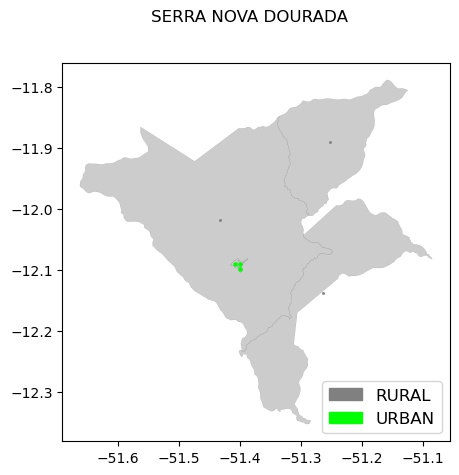

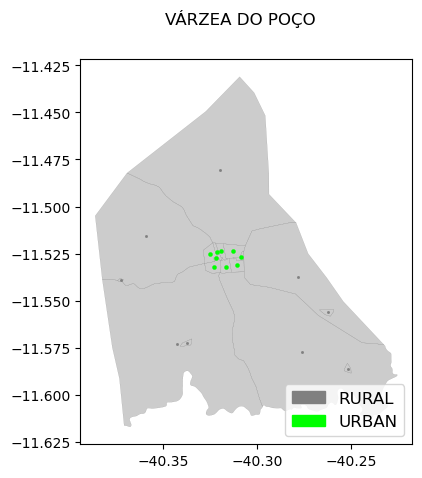

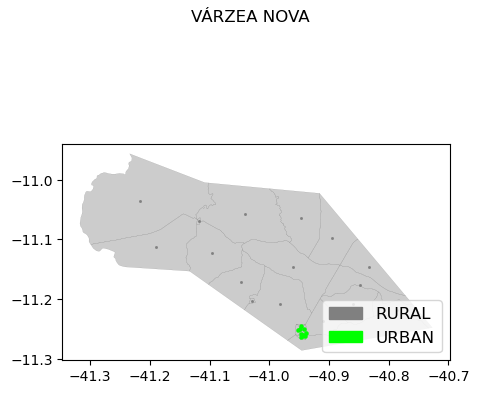

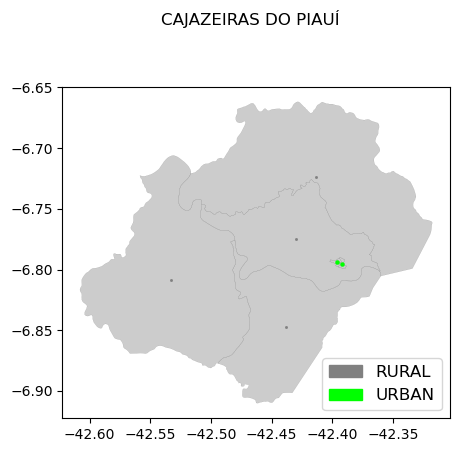

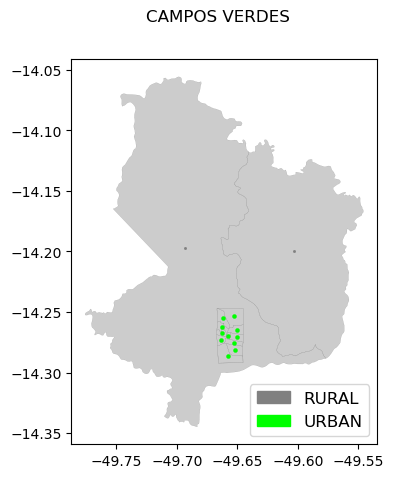

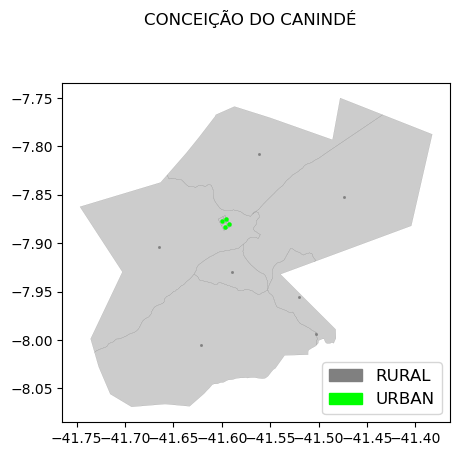

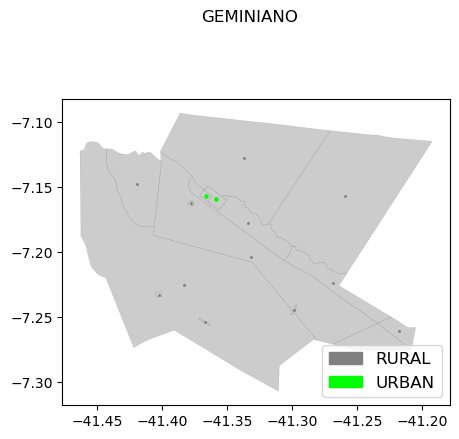

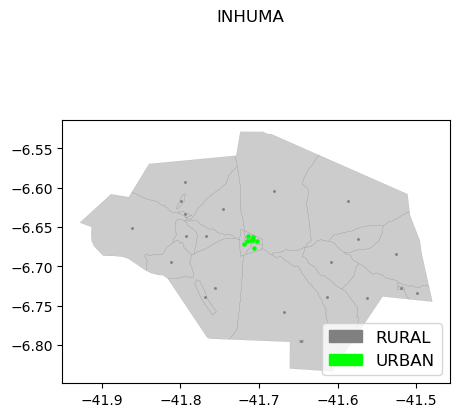

In [141]:
%matplotlib inline
for s in range(17,25):
    fig, ax = plt.subplots(figsize=(5,5))
    #sample='BARRA DO TURVO'
    sample=municipiosMirror_Treated[s]
    plt.suptitle(sample)
    df_temp1= df_BR_available[df_BR_available['NM_MUNICIP'] == sample]
    # Plot centroid of municipality
    df1= df_temp1[df_temp1['TIPO'] == 'URBANO']
    df2= df_temp1[df_temp1['TIPO'] == 'RURAL']

    df_temp2= geo_Brazil[geo_Brazil['NM_MUNICIP'] == sample]
    df_temp2['geometry'].plot(ax=ax,facecolor='gray',alpha=0.4, edgecolor='black', linewidth=0.1) #contourn 

    # plt.scatter(x=df_temp1['lon'], y=df_temp1['lat'],facecolor='red', alpha=0.8, linewidth=0.5, s=10) 
    df1['Center_point'].plot(ax=ax, facecolor='lime', alpha=1, linewidth=0.1, markersize=10) #URBANO
    df2['Center_point'].plot(ax=ax, facecolor='gray', alpha=1, linewidth=0.1, markersize=4) #RURAL

    ax.legend(handles=[Patch(facecolor='gray', edgecolor='gray',label='RURAL'),\
        Patch(facecolor='lime',edgecolor='lime', label='URBAN')],\
        loc='lower right',
        fontsize=12)

 
    # plt.savefig(fname=os.path.join('VR_urban_rural.png'), dpi=300, facecolor='w', edgecolor='w', transparent=True)

In [142]:
df_BR_available.columns

Index(['Cod_setor', 'TIPO', 'is_mirror', 'NM_MUNICIP', 'income', 'longevity',
       'literacy', 'IDH_CT', 'geometry', 'Center_point', 'lon', 'lat'],
      dtype='object')

In [143]:
#save csv processed
columns_to_show=['Cod_setor','lat', 'lon','TIPO','is_mirror','NM_MUNICIP','income','longevity','literacy','IDH_CT']
df_BR_available[columns_to_show].to_csv(os.path.join(OUTPUT_DIR, 'BR_PARSEC_clusters.csv'), sep=";", quotechar='"', encoding="utf-8", index=False)
  